In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Preapare Dataset

In [2]:
file_path = Path.home() / 'Documents/IDX Internship/Raw Data'

# 12 months of data from 6/2025-5/2026
files = [
    file_path / 'CRMLSSold202506.csv', file_path / 'CRMLSSold202507.csv',
    file_path / 'CRMLSSold202508.csv', file_path / 'CRMLSSold202509.csv',
    file_path / 'CRMLSSold202510.csv', file_path / 'CRMLSSold202511.csv',
    file_path / 'CRMLSSold202512.csv', file_path / 'CRMLSSold202601.csv',
    file_path / 'CRMLSSold202602.csv', file_path / 'CRMLSSold202603.csv',
    file_path / 'CRMLSSold202604.csv', file_path / 'CRMLSSold202605.csv',
]

# WaterfrontYN and PostalCode set to str dtype to handle mixed value types
data_dfs = [pd.read_csv(f, dtype={'WaterfrontYN': str, 'PostalCode': str}) for f in files]
df = pd.concat(data_dfs, ignore_index=True)
print(df.shape)

(258669, 78)


## Filter Dataset

In [3]:
# restrict analysis to residential and single family
df = df[
    (df['PropertyType'] == 'Residential') &
    (df['PropertySubType'] == 'SingleFamilyResidence')].copy()

print(df.shape)

(130220, 78)


## ClosePrice Distribution

In [4]:
print(df['ClosePrice'].size)
print(df[df['ClosePrice'] > 20000000]['ClosePrice'].size)

130220
102


Text(0.5, 1.0, 'ClosePrice Distribution')

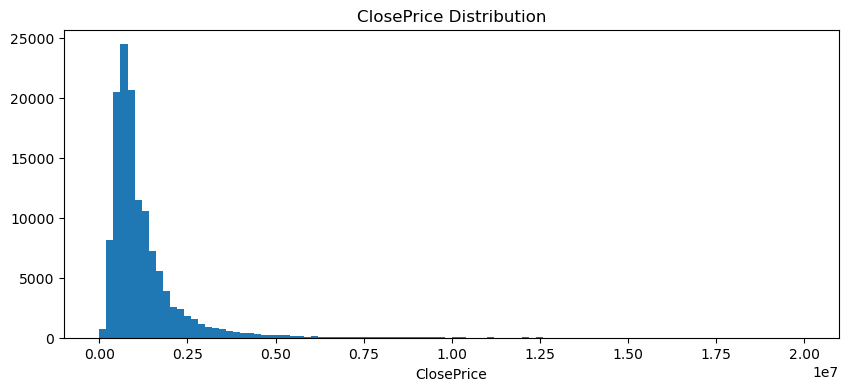

In [5]:
plt.figure(figsize=(10,4))
plt.hist(df[df['ClosePrice'] < 20000000]['ClosePrice'], bins=100)
plt.xlabel('ClosePrice')
plt.title('ClosePrice Distribution')

## LivingArea Distribution

In [8]:
print(df['LivingArea'].size)
print(df[df['LivingArea'] > 20000]['LivingArea'].size)

130220
4


Text(0.5, 1.0, 'LivingArea Distribution')

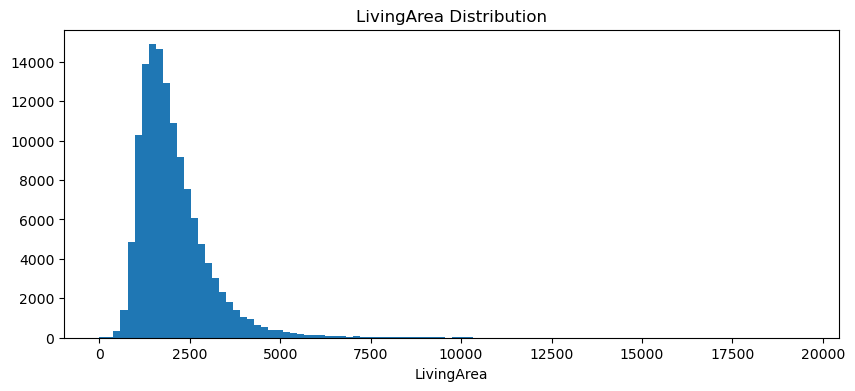

In [9]:
# LivingArea distribution
plt.figure(figsize=(10, 4))
plt.hist(df[df['LivingArea'] < 20000]['LivingArea'], bins=100)
plt.xlabel('LivingArea')
plt.title('LivingArea Distribution')

## Bedrooms Distribution

In [10]:
print(df['BedroomsTotal'].size)
print(df[df['BedroomsTotal'] > 15]['BedroomsTotal'].size)

130220
4


Text(0.5, 1.0, 'BedroomsTotal Distribution')

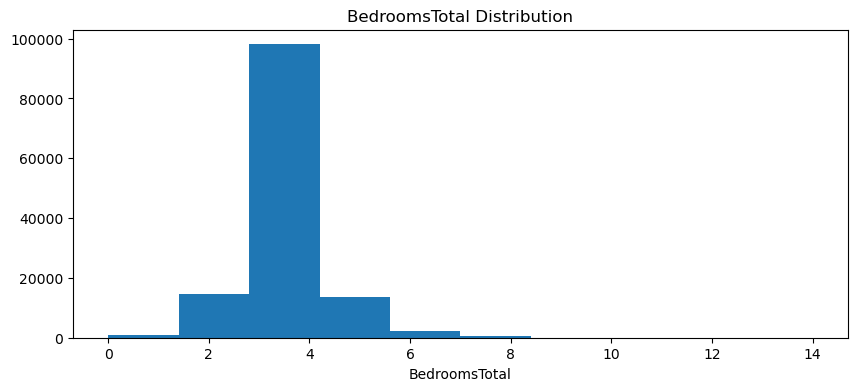

In [11]:
plt.figure(figsize=(10, 4))
plt.hist(df[df['BedroomsTotal'] < 15]['BedroomsTotal'])
plt.xlabel('BedroomsTotal')
plt.title('BedroomsTotal Distribution')

## Bathrooms Distribution

In [12]:
print(df['BathroomsTotalInteger'].size)
print(df[df['BathroomsTotalInteger'] > 20]['BathroomsTotalInteger'].size)

130220
4


Text(0.5, 1.0, 'BathroomsTotalInteger Distribution')

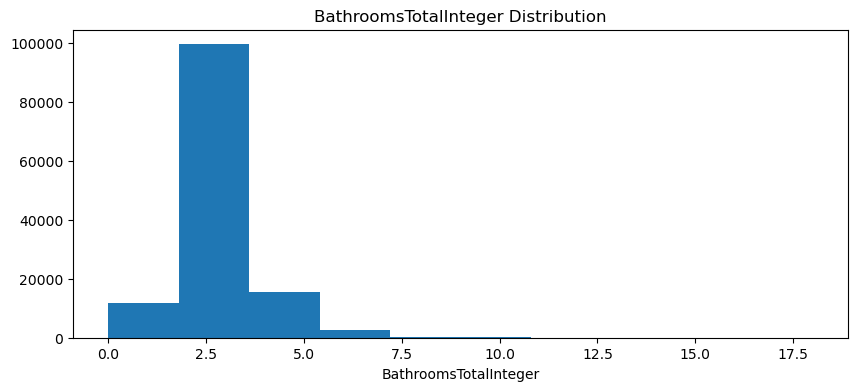

In [13]:
plt.figure(figsize=(10, 4))
plt.hist(df[df['BathroomsTotalInteger'] < 20]['BathroomsTotalInteger'])
plt.xlabel('BathroomsTotalInteger')
plt.title('BathroomsTotalInteger Distribution')

## LotSize Distribution

In [14]:
print(df['LotSizeArea'].size)
print(df[df['LotSizeArea'] > 50000]['LotSizeArea'].size)

130220
4810


Text(0.5, 1.0, 'LotSizeArea Distribution')

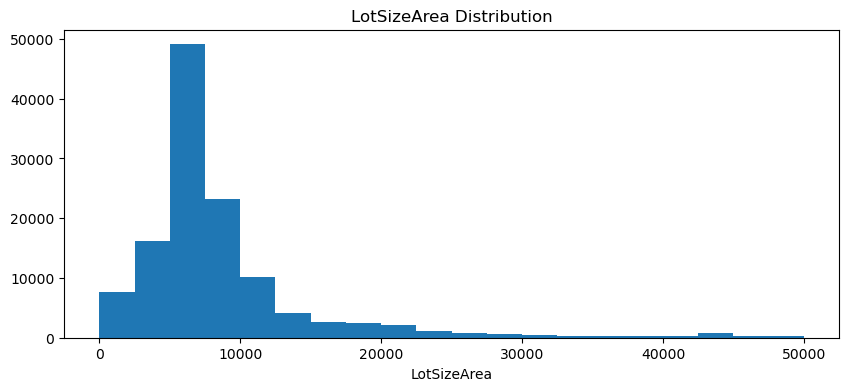

In [15]:
plt.figure(figsize=(10, 4))
plt.hist(df[df['LotSizeArea'] < 50000]['LotSizeArea'], bins=20)
plt.xlabel('LotSizeArea')
plt.title('LotSizeArea Distribution')